In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<ipython-input-13-6cc2a6022caa>:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('tab20')


<ipython-input-23-522645682237>:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('tab20')


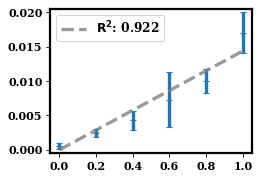

In [23]:
plt.rc('font', family = 'serif', size = 15, weight = "bold")
plt.rc('xtick', labelsize = 10)
plt.rc('ytick', labelsize = 10)
plt.rc('axes', linewidth = 2)
plt.rc('lines', linewidth = 3)
plt.rc('legend', fontsize = 13)

cm = plt.cm.get_cmap('tab20')


# Load data
df = pd.read_excel('./Experimental-Data-Achrive.xlsx', sheet_name='Figure-4-d-fitting-result')

# Independent and dependent variables
x = np.array([1.0, 0.8, 0.6, 0.4, 0.2, 0.0])
y = df['Kp (mean)'].values
z = df['kp (std)'].values

# Reshape x for linear algebra
x_reshaped = x.reshape(-1, 1)

# Fit y = ax (no intercept)
a, _, _, _ = np.linalg.lstsq(x_reshaped, y, rcond=None)
y_pred = a[0] * x

# R^2
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - ss_res / ss_tot

# Plot
fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.errorbar(x, y, yerr=z, fmt='+', color='tab:blue', capsize=3)

# Regression line
x_line = np.linspace(0, 1.0, 100)
y_line = a[0] * x_line
ax.plot(x_line, y_line, '--', color='gray', alpha = .8,
        linewidth=3, label=f'$\\bf{{R^2}}$: {r_squared:.3f}')

# Styling

ax.legend(frameon=True, loc='upper left', fontsize=11)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.0005, .0205)
plt.tight_layout()

plt.savefig('figure-4d_fitting.svg', format='svg')

plt.show()
